# Pest Identification - TensorFlow Training Pipeline

End-to-end notebook: data discovery, preparation, preprocessing, visualization, training, evaluation, ROC-AUC, and model export.


**Section: Setup**

In [1]:
import os
import random
import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

import tensorflow as tf

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path('dataset')
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

# Preprocessing toggles
FILTER_QUALITY = True
BLUR_THRESHOLD = 15.0  # lower -> more strict (tune as needed)
BRIGHTNESS_MIN = 20.0  # 0-255
BRIGHTNESS_MAX = 235.0 # 0-255
USE_CACHE = True

# Training toggles
USE_FINE_TUNING = False  # set True to unfreeze top layers after initial training
FINE_TUNE_AT = 100       # unfreeze from this layer index in base model


2026-03-09 02:24:40.769704: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 02:24:40.773709: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 02:24:40.775764: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 02:24:40.802949: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 02:24:41.978518: W tensorflow/compiler/tf2tensorrt/utils/py_uti

**Section: Data Discovery**

**1) Dataset Scan**

In [2]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATA_DIR.resolve()}')

class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
if not class_names:
    raise ValueError('No class folders found inside dataset/')

print('Classes:', class_names)

image_paths = []
labels = []
for idx, cls in enumerate(class_names):
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        for p in (DATA_DIR / cls).glob(ext):
            image_paths.append(str(p))
            labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)
print('Total images:', len(image_paths))


Classes: ['Cecidomyiidae', 'Chloropidae', 'Cicadellidae', 'Crambidae', 'Curculionidae', 'Delphacidae', 'Nonpest', 'Phlaeothripidae']
Total images: 4499


**2) Per-Class Counts and Imbalance**

Counts per class:
Cecidomyiidae: 450
Chloropidae: 450
Cicadellidae: 450
Crambidae: 450
Curculionidae: 450
Delphacidae: 450
Nonpest: 1349
Phlaeothripidae: 450
Imbalance ratio (max/min): 3.00


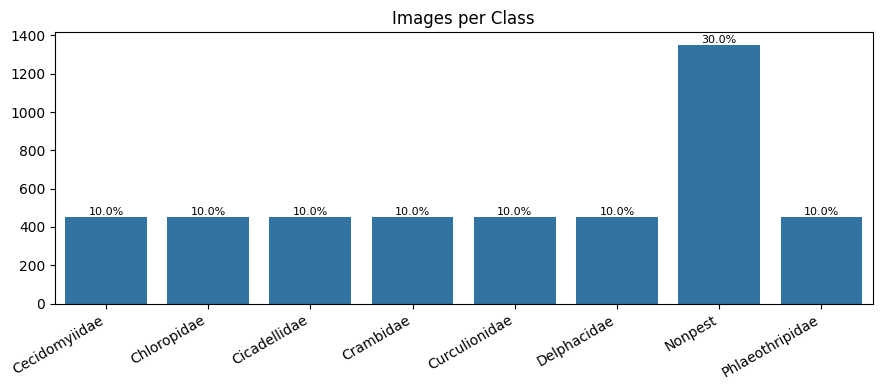

In [3]:
counts = Counter(labels)
counts_per_class = [counts[i] for i in range(len(class_names))]
min_c = min(counts_per_class)
max_c = max(counts_per_class)
imbalance_ratio = max_c / max(1, min_c)
print('Counts per class:')
for name, c in zip(class_names, counts_per_class):
    print(f'{name}: {c}')
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

# Bar chart with counts and percentages
total = sum(counts_per_class)
pct = [c / total * 100 for c in counts_per_class]
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=class_names, y=counts_per_class)
plt.xticks(rotation=30, ha='right')
plt.title('Images per Class')
for i, v in enumerate(counts_per_class):
    ax.text(i, v + max(counts_per_class) * 0.01, f'{pct[i]:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


**3) Image Size and Aspect Ratio Distribution**

Width: min=75 max=5616 mean=504.3
Height: min=75 max=6000 mean=446.5


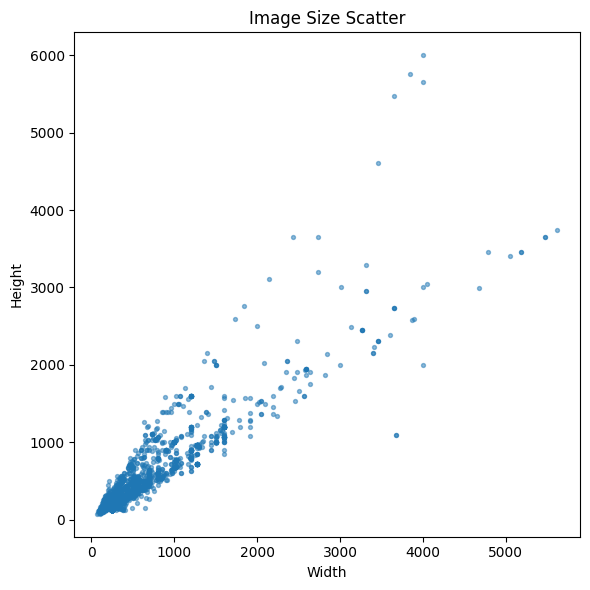

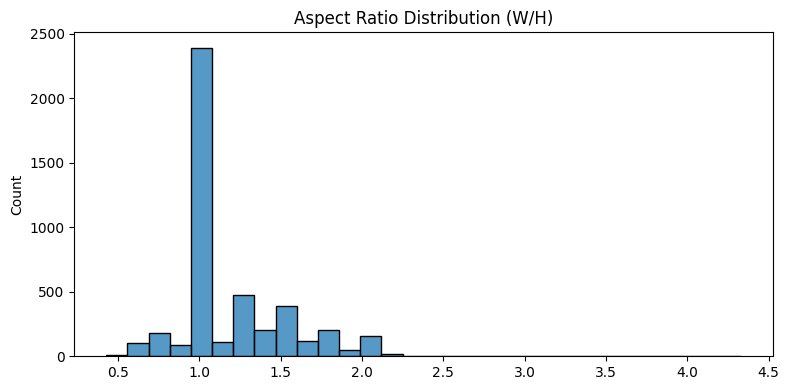

In [4]:
sizes = []
aspects = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            sizes.append((w, h))
            if h > 0:
                aspects.append(w / h)
    except Exception:
        pass

sizes = np.array(sizes)
if len(sizes) > 0:
    widths, heights = sizes[:, 0], sizes[:, 1]
    print(f'Width: min={widths.min()} max={widths.max()} mean={widths.mean():.1f}')
    print(f'Height: min={heights.min()} max={heights.max()} mean={heights.mean():.1f}')

    plt.figure(figsize=(6, 6))
    plt.scatter(widths, heights, s=8, alpha=0.5)
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.title('Image Size Scatter')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(aspects, bins=30)
    plt.title('Aspect Ratio Distribution (W/H)')
    plt.tight_layout()
    plt.show()


**4) Corrupt / Unreadable Image Detection**

In [5]:
bad_files = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            img.verify()
    except Exception:
        bad_files.append(p)

print(f'Corrupt or unreadable images: {len(bad_files)}')
if bad_files[:10]:
    print('Examples:')
    for bf in bad_files[:10]:
        print(' -', bf)


Corrupt or unreadable images: 0


**5) Duplicate / Near-Duplicate Detection (Perceptual Hash)**

In [6]:
# Warning: This can be slow on large datasets
hashes = {}
duplicates = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            h = imagehash.phash(img)
        if h in hashes:
            duplicates.append((hashes[h], p))
        else:
            hashes[h] = p
    except Exception:
        pass

print(f'Exact/near duplicates found: {len(duplicates)}')
if duplicates[:10]:
    print('Examples:')
    for a, b in duplicates[:10]:
        print(' -', a, '==', b)


Exact/near duplicates found: 1026
Examples:
 - dataset/Cecidomyiidae/5 (511).jpg == dataset/Cecidomyiidae/5 (527).jpg
 - dataset/Cecidomyiidae/5 (475).jpg == dataset/Cecidomyiidae/5 (538).jpg
 - dataset/Cecidomyiidae/5 (486).jpg == dataset/Cecidomyiidae/5 (539).jpg
 - dataset/Cecidomyiidae/5 (507).jpg == dataset/Cecidomyiidae/5 (540).jpg
 - dataset/Cecidomyiidae/5 (508).jpg == dataset/Cecidomyiidae/5 (542).jpg
 - dataset/Cecidomyiidae/5 (480).jpg == dataset/Cecidomyiidae/5 (545).jpg
 - dataset/Cecidomyiidae/5 (546).jpg == dataset/Cecidomyiidae/5 (552).jpg
 - dataset/Cecidomyiidae/5 (535).jpg == dataset/Cecidomyiidae/5 (554).jpg
 - dataset/Cecidomyiidae/5 (547).jpg == dataset/Cecidomyiidae/5 (563).jpg
 - dataset/Cecidomyiidae/5 (507).jpg == dataset/Cecidomyiidae/5 (565).jpg


**6) Brightness Distribution**

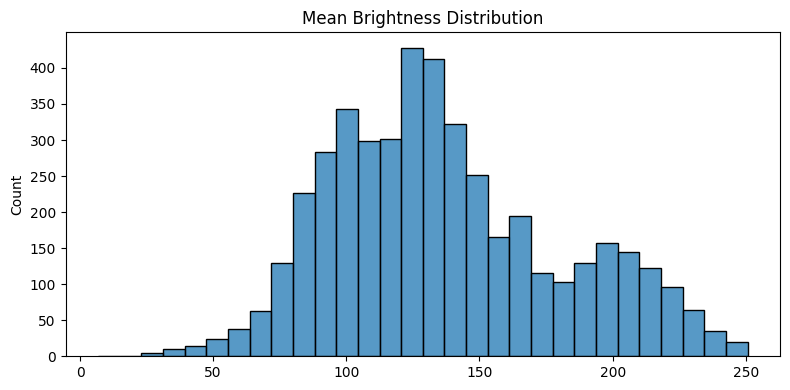

In [7]:
brightness_vals = []
brightness_labels = []
for p, y in zip(image_paths, labels):
    try:
        with Image.open(p).convert('L') as img:
            arr = np.array(img, dtype=np.float32)
            brightness_vals.append(arr.mean())
            brightness_labels.append(y)
    except Exception:
        pass

plt.figure(figsize=(8, 4))
sns.histplot(brightness_vals, bins=30)
plt.title('Mean Brightness Distribution')
plt.tight_layout()
plt.show()


**6b) Brightness by Class**

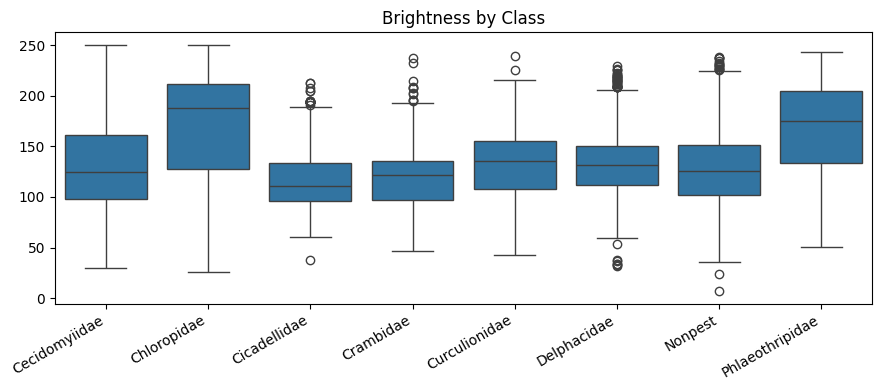

In [8]:
if len(brightness_vals) > 0:
    plt.figure(figsize=(9, 4))
    data = []
    for b, y in zip(brightness_vals, brightness_labels):
        data.append((class_names[y], b))
    xs = [d[0] for d in data]
    ys = [d[1] for d in data]
    sns.boxplot(x=xs, y=ys)
    plt.xticks(rotation=30, ha='right')
    plt.title('Brightness by Class')
    plt.tight_layout()
    plt.show()


**7) Visual Label Audit (Sample per Class)**

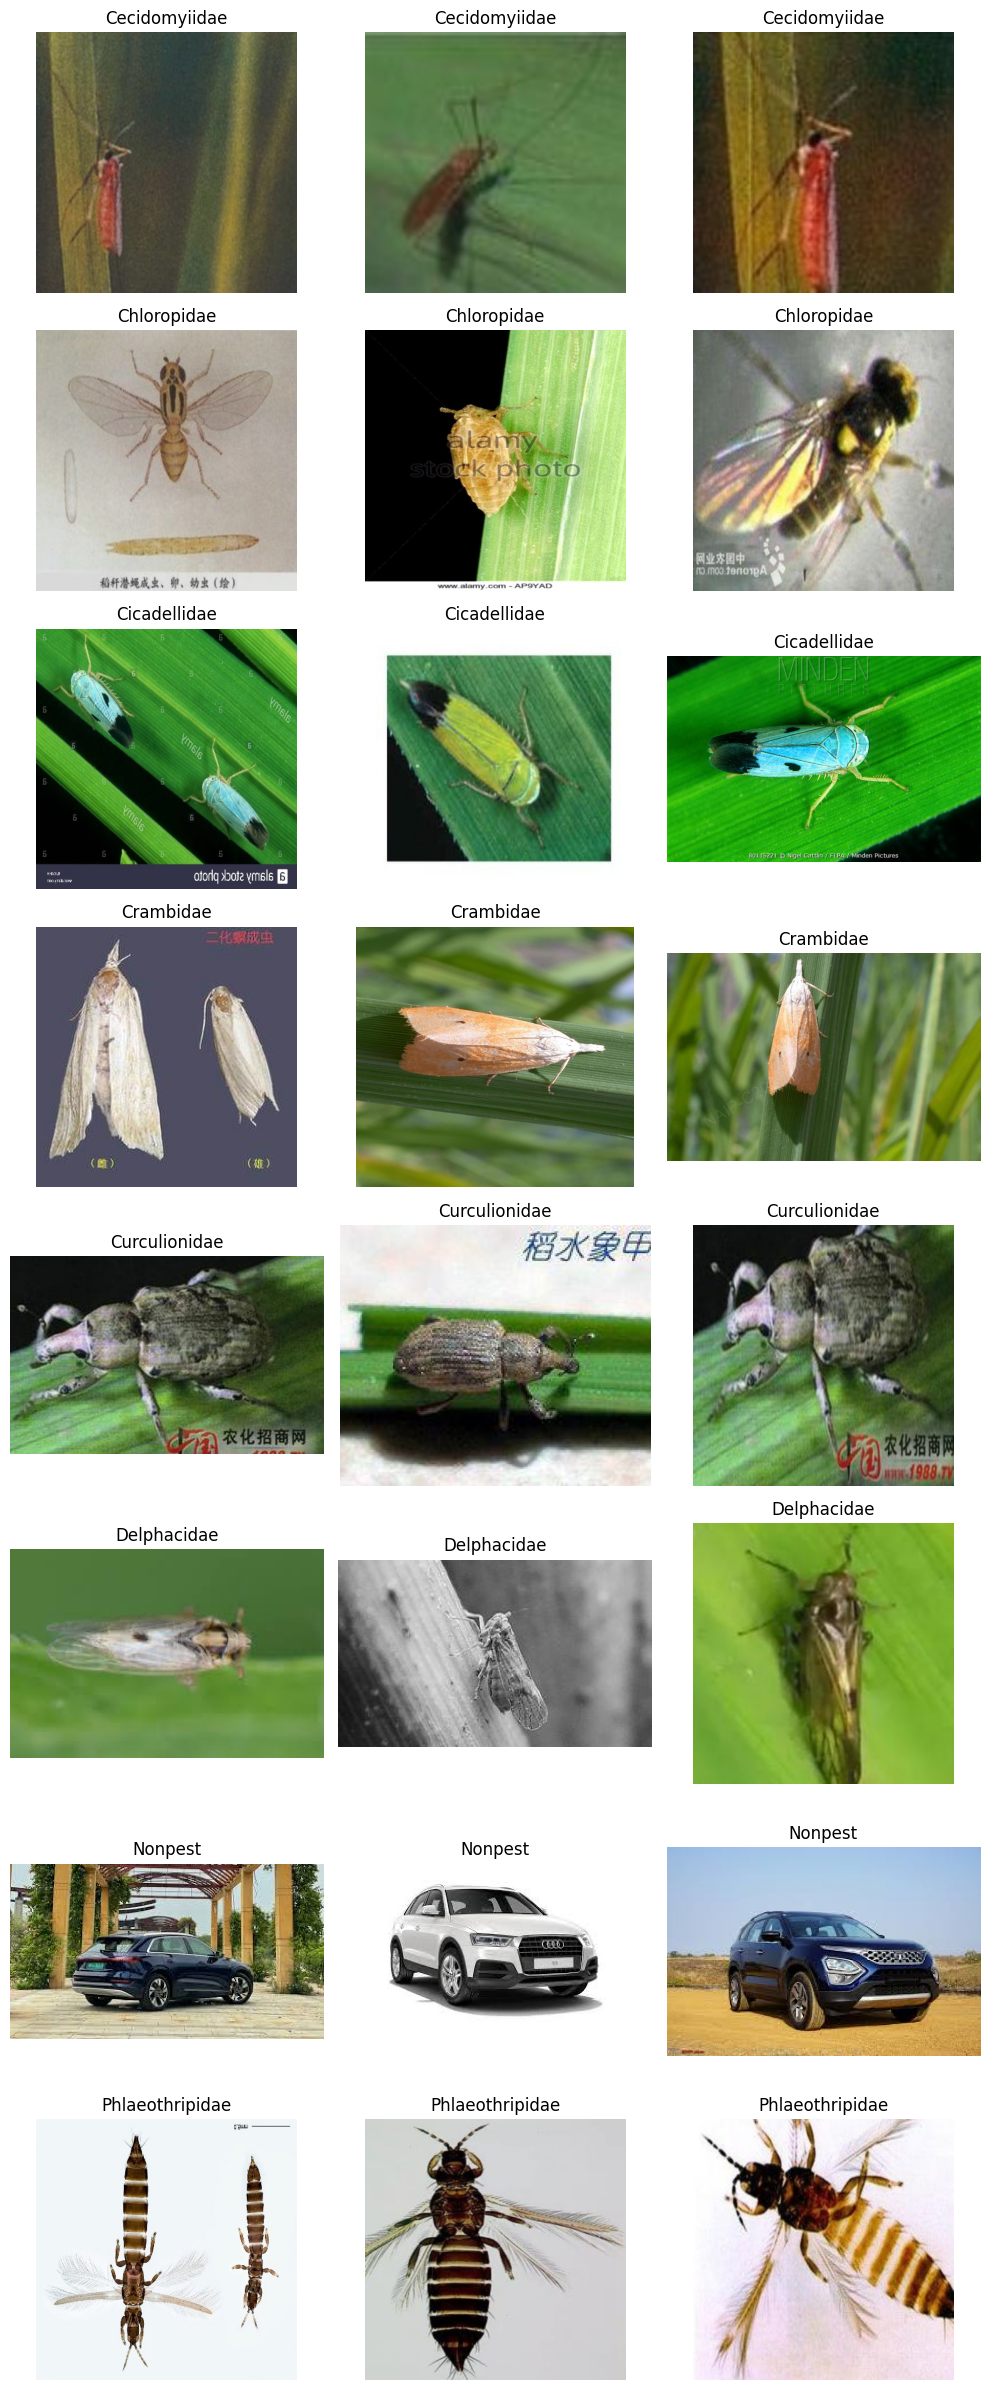

In [9]:
samples_per_class = 3
plt.figure(figsize=(10, 3 * len(class_names)))
row = 0
for idx, cls in enumerate(class_names):
    cls_paths = [p for p, y in zip(image_paths, labels) if y == idx]
    random.shuffle(cls_paths)
    for i in range(min(samples_per_class, len(cls_paths))):
        ax = plt.subplot(len(class_names), samples_per_class, row + i + 1)
        img = Image.open(cls_paths[i])
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
    row += samples_per_class
plt.tight_layout()
plt.show()


**8) Train/Val/Test Split (Stratified) and Check**

In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

def show_split_stats(name, lbls):
    c = Counter(lbls)
    print(name)
    for i, cls in enumerate(class_names):
        print(f'  {cls}: {c.get(i, 0)}')

show_split_stats('Train', train_labels)
show_split_stats('Val', val_labels)
show_split_stats('Test', test_labels)


Train
  Cecidomyiidae: 315
  Chloropidae: 315
  Cicadellidae: 315
  Crambidae: 315
  Curculionidae: 315
  Delphacidae: 315
  Nonpest: 944
  Phlaeothripidae: 315
Val
  Cecidomyiidae: 68
  Chloropidae: 68
  Cicadellidae: 67
  Crambidae: 67
  Curculionidae: 67
  Delphacidae: 68
  Nonpest: 202
  Phlaeothripidae: 68
Test
  Cecidomyiidae: 67
  Chloropidae: 67
  Cicadellidae: 68
  Crambidae: 68
  Curculionidae: 68
  Delphacidae: 67
  Nonpest: 203
  Phlaeothripidae: 67


**9) Class Similarity Check (Quick Embedding + PCA)**

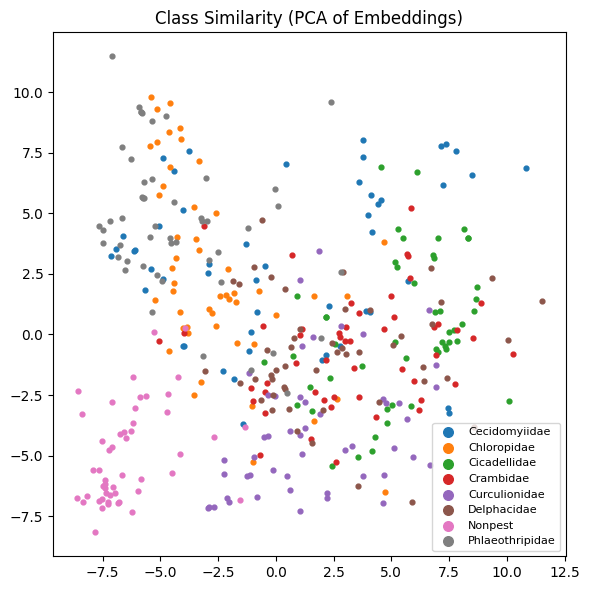

In [11]:
# Optional: quick clustering view using a pretrained encoder
# Sample up to 50 images per class for speed
sample_paths = []
sample_labels = []
max_per_class = 50
for i, cls in enumerate(class_names):
    cls_paths = [p for p, y in zip(image_paths, labels) if y == i]
    random.shuffle(cls_paths)
    take = cls_paths[:max_per_class]
    sample_paths.extend(take)
    sample_labels.extend([i] * len(take))

def load_img_array(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img

encoder = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg'
)

sample_ds = tf.data.Dataset.from_tensor_slices(sample_paths)
sample_ds = sample_ds.map(load_img_array, num_parallel_calls=AUTOTUNE).batch(32)
features = encoder.predict(sample_ds, verbose=0)
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(features)

plt.figure(figsize=(6, 6))
for i, cls in enumerate(class_names):
    idxs = [j for j, y in enumerate(sample_labels) if y == i]
    plt.scatter(coords[idxs, 0], coords[idxs, 1], label=cls, s=12)
plt.title('Class Similarity (PCA of Embeddings)')
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


**Section: Data Preprocessing**

**1) Quality Filtering (Blurry / Too Dark / Too Bright)**

In [12]:
def sharpness_score(gray_arr):
    # Simple Laplacian-based sharpness approximation
    lap = (
        -4 * gray_arr
        + np.roll(gray_arr, 1, 0) + np.roll(gray_arr, -1, 0)
        + np.roll(gray_arr, 1, 1) + np.roll(gray_arr, -1, 1)
    )
    return lap.var()

def image_quality_ok(path):
    try:
        with Image.open(path).convert('L') as img:
            arr = np.array(img, dtype=np.float32)
        mean_brightness = arr.mean()
        sharpness = sharpness_score(arr)
        if mean_brightness < BRIGHTNESS_MIN or mean_brightness > BRIGHTNESS_MAX:
            return False
        if sharpness < BLUR_THRESHOLD:
            return False
        return True
    except Exception:
        return False

if FILTER_QUALITY:
    keep_paths = []
    keep_labels = []
    removed = 0
    for p, y in zip(image_paths, labels):
        if image_quality_ok(p):
            keep_paths.append(p)
            keep_labels.append(y)
        else:
            removed += 1
    image_paths = np.array(keep_paths)
    labels = np.array(keep_labels)
    print(f'Removed {removed} low-quality images')
    print(f'Remaining images: {len(image_paths)}')


Removed 106 low-quality images
Remaining images: 4393


**2) Train/Val/Test Split After Filtering**

In [13]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)


**3) Class Weights for Imbalance**

In [14]:
counts = Counter(train_labels)
total = len(train_labels)
class_weight = {i: total / (len(class_names) * counts.get(i, 1)) for i in range(len(class_names))}
print('Class weights:', class_weight)


Class weights: {0: 1.3392857142857142, 1: 1.28125, 2: 1.2202380952380953, 3: 1.2280351437699681, 4: 1.2359324758842443, 5: 1.2280351437699681, 6: 0.4124195278969957, 7: 1.264391447368421}


**4) TF Dataset + Caching**

In [15]:
NUM_CLASSES = len(class_names)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.convert_image_dtype(img, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if USE_CACHE:
        ds = ds.cache()
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_paths, train_labels, training=True)
val_ds = build_dataset(val_paths, val_labels)
test_ds = build_dataset(test_paths, test_labels)


**Section: Visualization (Improved)**

**1) Sample Images**

2026-03-09 02:25:22.615880: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the

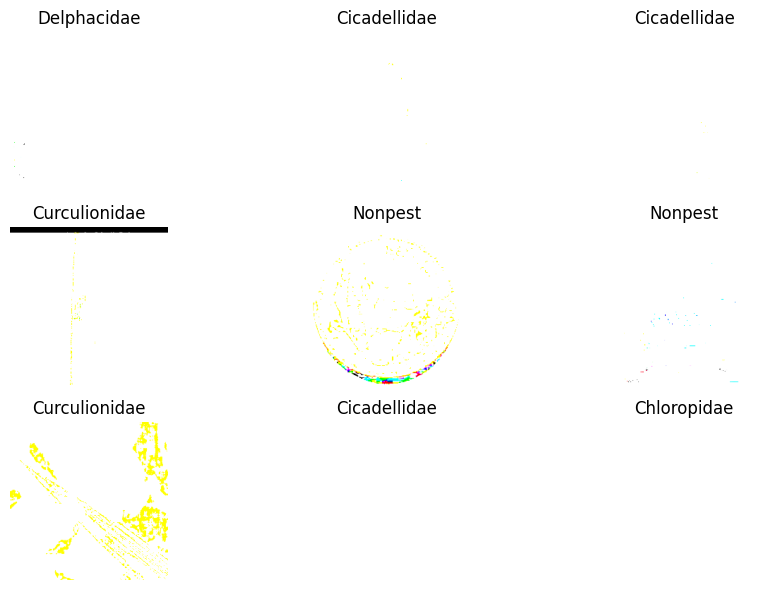

In [16]:
plt.figure(figsize=(10, 6))
for images, labels_batch in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label_idx = int(tf.argmax(labels_batch[i]).numpy())
        plt.title(class_names[label_idx])
        plt.axis('off')
plt.tight_layout()
plt.show()


**2) Augmentation Preview**

2026-03-09 02:25:22.849667: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the

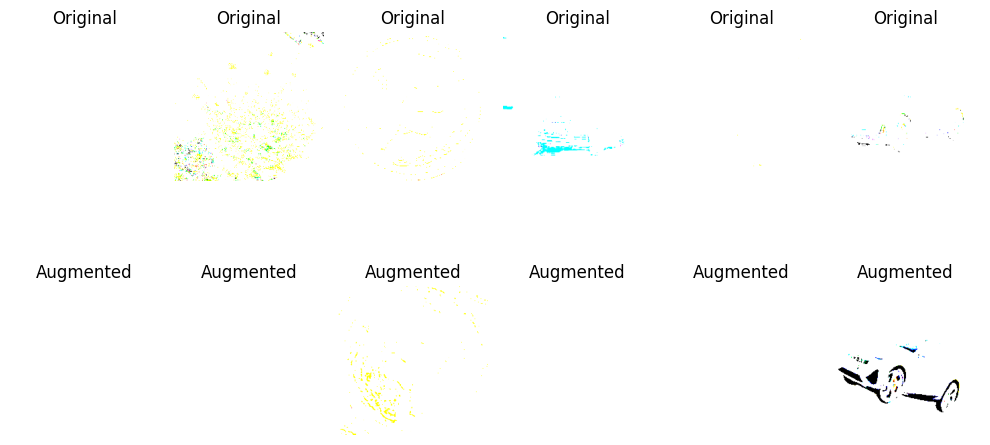

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

# Take a small batch and show original vs augmented
sample_batch = next(iter(train_ds))
images, labels_batch = sample_batch
augmented = data_augmentation(images)

plt.figure(figsize=(10, 6))
for i in range(min(6, images.shape[0])):
    ax = plt.subplot(2, 6, i + 1)
    plt.imshow(images[i])
    plt.title('Original')
    plt.axis('off')
    ax = plt.subplot(2, 6, i + 7)
    plt.imshow(augmented[i])
    plt.title('Augmented')
    plt.axis('off')
plt.tight_layout()
plt.show()


**Section: Model**

In [18]:
# Use the same augmentation in the model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Section: Training (Stage 1 - Frozen Base)**

In [19]:
Path('models').mkdir(exist_ok=True)
checkpoint_path = 'models/best_model.keras'

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.7808 - loss: 0.7851 - top3_acc: 0.9220 - val_accuracy: 0.9332 - val_loss: 0.2634 - val_top3_acc: 0.9879 - learning_rate: 0.0010
Epoch 2/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9265 - loss: 0.3032 - top3_acc: 0.9909 - val_accuracy: 0.9530 - val_loss: 0.1887 - val_top3_acc: 0.9894 - learning_rate: 0.0010
Epoch 3/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9473 - loss: 0.2207 - top3_acc: 0.9928 - val_accuracy: 0.9681 - val_loss: 0.1505 - val_top3_acc: 0.9924 - learning_rate: 0.0010
Epoch 4/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.9590 - loss: 0.1804 - top3_acc: 0.9958 - val_accuracy: 0.9651 - val_loss: 0.1431 - val_top3_acc: 0.9954 - learning_rate: 0.0010
Epoch 5/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.9597 - loss: 0.1607 - top3_acc: 0.9961 - val_accuracy: 0.9697 - val_loss: 0.1187 - val_top3_acc: 0.9970 - learning_rate: 0.0010
Epoch 6/15
193/193 ━

**Section: Optional Fine-Tuning (Stage 2)**

In [20]:
if USE_FINE_TUNING:
    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS // 2 + 1,
        callbacks=callbacks,
        class_weight=class_weight
    )


**Section: Training Curves (Improved)**

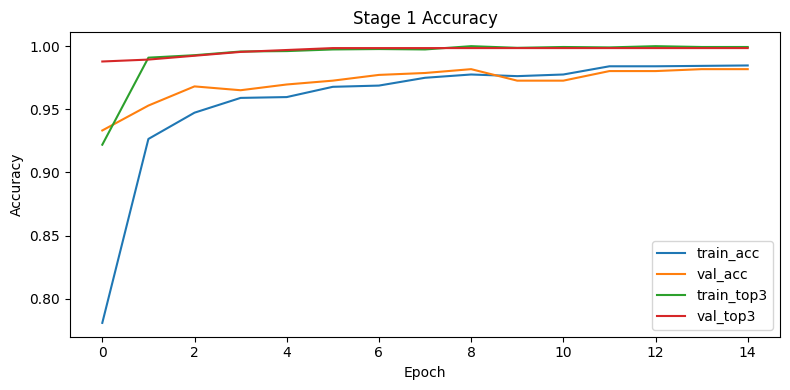

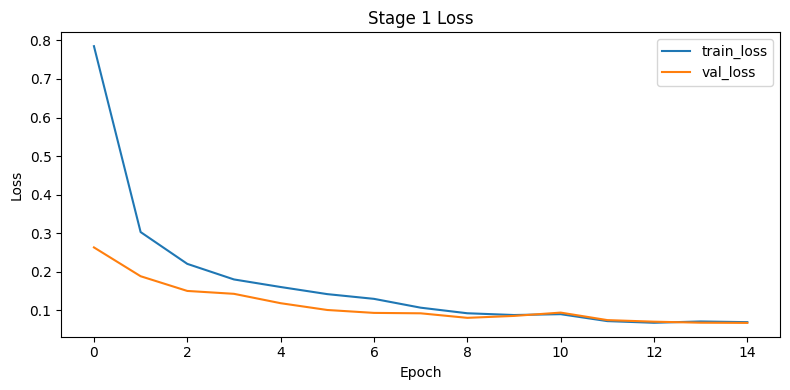

In [21]:
def plot_history(hist, title_prefix=''):
    plt.figure(figsize=(8, 4))
    plt.plot(hist.history['accuracy'], label='train_acc')
    plt.plot(hist.history['val_accuracy'], label='val_acc')
    if 'top3_acc' in hist.history:
        plt.plot(hist.history['top3_acc'], label='train_top3')
        plt.plot(hist.history['val_top3_acc'], label='val_top3')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix}Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(hist.history['loss'], label='train_loss')
    plt.plot(hist.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix}Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history, title_prefix='Stage 1 ')
if USE_FINE_TUNING:
    plot_history(history_ft, title_prefix='Stage 2 ')


**Section: Evaluation (Improved)**

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9651 - loss: 0.1316 - top3_acc: 0.9924
Test accuracy: 0.9651
Test top-3 accuracy: 0.9924


2026-03-09 02:29:27.334782: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


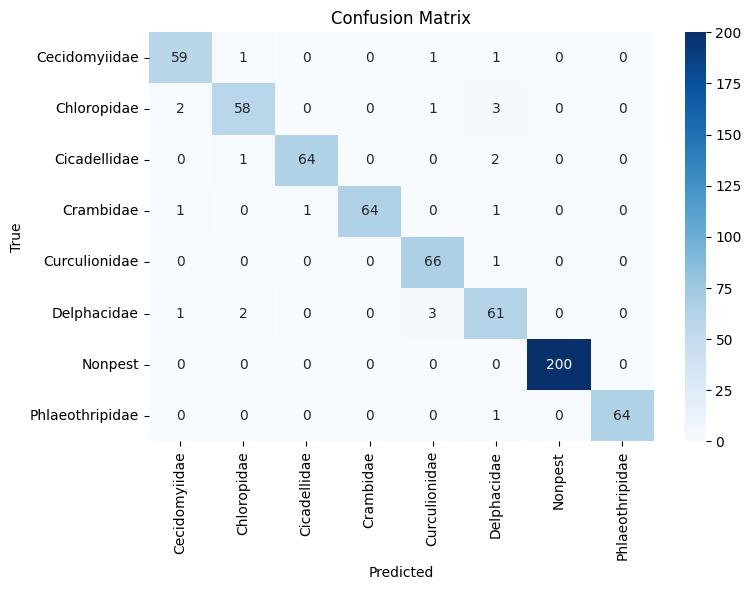

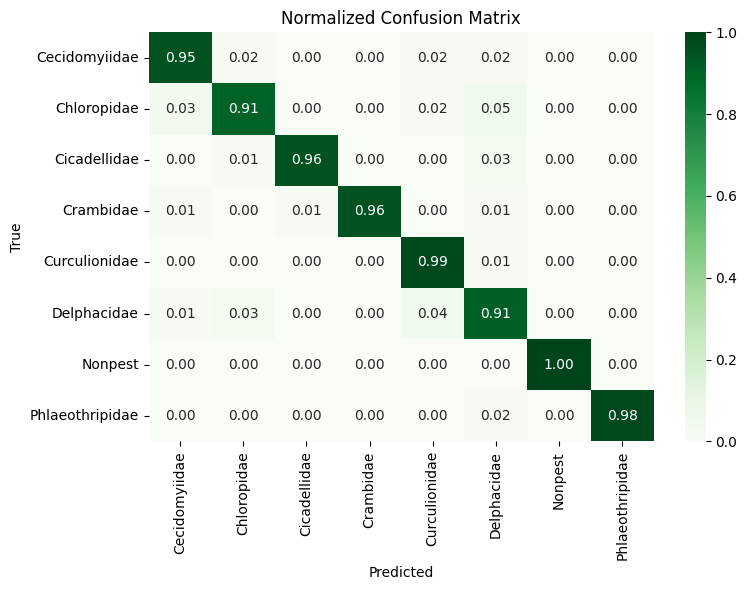

                 precision    recall  f1-score   support

  Cecidomyiidae       0.94      0.95      0.94        62
    Chloropidae       0.94      0.91      0.92        64
   Cicadellidae       0.98      0.96      0.97        67
      Crambidae       1.00      0.96      0.98        67
  Curculionidae       0.93      0.99      0.96        67
    Delphacidae       0.87      0.91      0.89        67
        Nonpest       1.00      1.00      1.00       200
Phlaeothripidae       1.00      0.98      0.99        65

       accuracy                           0.97       659
      macro avg       0.96      0.96      0.96       659
   weighted avg       0.97      0.97      0.97       659



In [22]:
test_loss, test_acc, test_top3 = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test top-3 accuracy: {test_top3:.4f}')

y_true = []
y_pred = []
y_score = []
for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


**Section: ROC-AUC Curves (One-vs-Rest)**

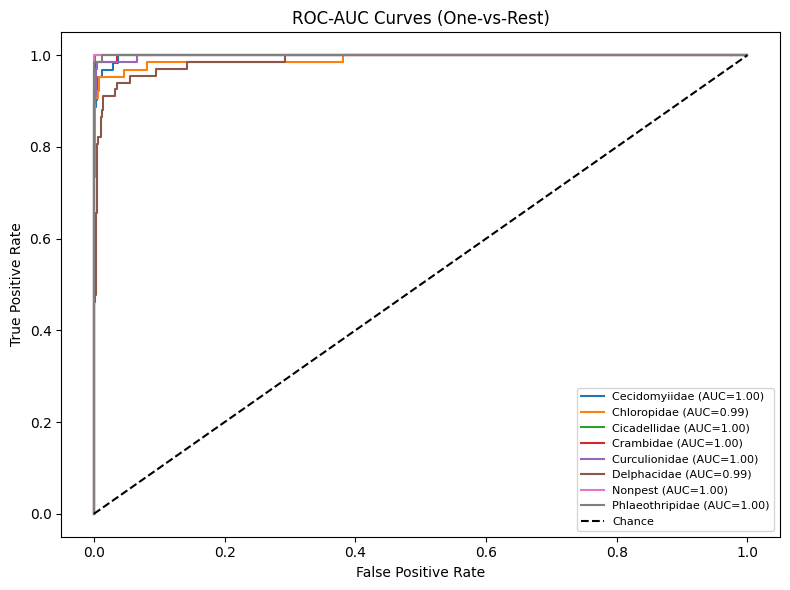

In [23]:
# Binarize labels for ROC
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f'{cls} (AUC={roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves (One-vs-Rest)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Section: Export (Formats and Metadata)**

In [24]:
# Save in Keras V3 format (.keras), H5, TensorFlow SavedModel, and TFLite
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

keras_path = models_dir / 'pest_classifier.keras'
h5_path = models_dir / 'pest_classifier.h5'
weights_h5_path = models_dir / 'pest_classifier.weights.h5'
saved_model_dir = models_dir / 'pest_classifier_savedmodel'
tflite_path = models_dir / 'pest_classifier.tflite'
class_names_path = models_dir / 'class_names.json'

model.save(keras_path)

# H5 is legacy in Keras 3; try full model save, fallback to weights-only
try:
    model.save(h5_path, include_optimizer=False)
    h5_note = 'Saved full model to H5.'
except Exception as e:
    model.save_weights(weights_h5_path)
    h5_note = f'Failed full H5 save ({e}). Saved weights only to {weights_h5_path}.'

model.export(saved_model_dir)

# TFLite conversion (use SavedModel path for better compatibility)
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    tflite_model = converter.convert()
    tflite_path.write_bytes(tflite_model)
    tflite_note = 'Saved TFLite model from SavedModel.'
except Exception as e:
    # Fallback to direct conversion from Keras model
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS,
    ]
    tflite_model = converter.convert()
    tflite_path.write_bytes(tflite_model)
    tflite_note = f'Fallback TFLite conversion used ({e}).'

class_names_path.write_text(json.dumps(class_names, indent=2))

print(f'Saved Keras model: {keras_path}')
print(f'Saved H5 model: {h5_path} -> {h5_note}')
print(f'Saved SavedModel: {saved_model_dir}')
print(f'Saved TFLite model: {tflite_path} -> {tflite_note}')
print(f'Saved class names: {class_names_path}')


INFO:tensorflow:Assets written to: models/pest_classifier_savedmodel/assets


INFO:tensorflow:Assets written to: models/pest_classifier_savedmodel/assets


Saved artifact at 'models/pest_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_315')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  128655705292048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128655705292240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142604880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142605072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142606416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142604304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142608144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142609872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142607568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128654142609104: TensorSpec(shape=(), dtype=tf.resource, name=N

W0000 00:00:1773003571.364900   49695 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1773003571.364926   49695 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-03-09 02:29:31.365360: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: models/pest_classifier_savedmodel
2026-03-09 02:29:31.373919: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-09 02:29:31.373938: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: models/pest_classifier_savedmodel
2026-03-09 02:29:31.466771: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-03-09 02:29:31.476511: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-03-09 02:29:31.841905: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: models/pest_classifier_savedmodel
2026-03-09 02: